#


In [8]:
base_path = "../memoriaLatex"

In [9]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from noisers.classes import URLFNoise
from filters import ClassificationFilter
# 1. Generar un conjunto de datos de ejemplo
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=0
)
# 2. Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 3. Añadir ruido a las etiquetas del conjunto de entrenamiento
noise_k=0.15
noiser = URLFNoise(noise_level=noise_k, random_state=42)
X_train_noisy, y_train_noisy = noiser.fit_resample(X_train, y_train)
# 4. Aplicar un filtro de ruido
filter_ = ClassificationFilter(estimator=KNeighborsClassifier(n_neighbors=3), cv=10)
X_clean, y_clean = filter_.fit_resample(X_train, y_train_noisy)

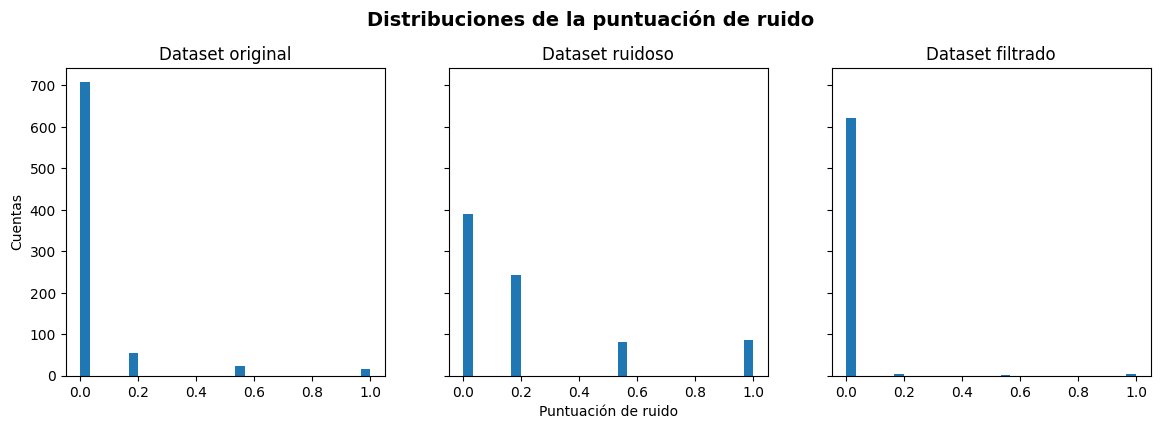

In [10]:
clean_noiseScore = filter_.fit(X_train, y_train).noise_score_
noisy_noiseScore = filter_.fit(X_train, y_train_noisy).noise_score_
filtered_noiseScore = filter_.fit(X_clean, y_clean).noise_score_

import matplotlib.pyplot as plt
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(14,4))


ax1.set_title("Dataset original")
ax1.set_ylabel("Cuentas")
ax1.hist(clean_noiseScore, bins=30)


ax2.set_title("Dataset ruidoso")
ax2.tick_params(axis='y', labelleft=False)
ax2.set_xlabel("Puntuación de ruido")
ax2.hist(noisy_noiseScore, bins=30)

ax3.set_title("Dataset filtrado")
ax3.tick_params(axis='y', labelleft=False)
ax3.hist(filtered_noiseScore, bins=30)

plt.suptitle("Distribuciones de la puntuación de ruido", y=1.025, fontsize=14, fontweight=600)
plt.savefig(base_path+f"/img/libDesc/nsDistributionFilteringExample.png", bbox_inches="tight")
plt.show()

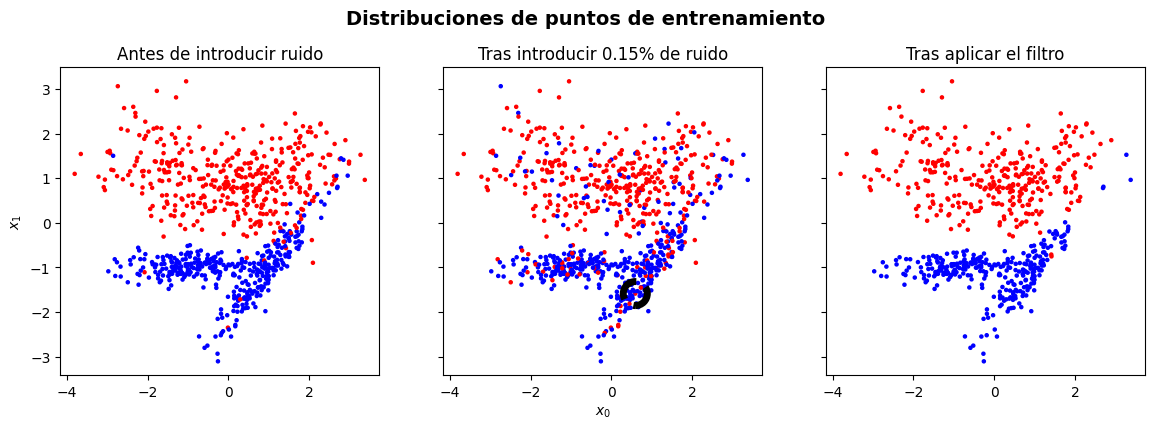

In [11]:
import numpy as np
noisiest_idx = np.argwhere(noisy_noiseScore == np.amax(noisy_noiseScore))[0]

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.title("Antes de introducir ruido")
plt.ylabel(r"$x_1$")
plt.scatter(X_train[:,0],X_train[:,1], c=y_train, s=5, cmap="bwr")

plt.subplot(1,3,2)
plt.title(f"Tras introducir {noise_k}% de ruido")
plt.tick_params(axis='y', labelleft=False)
plt.xlabel(r"$x_0$")
plt.scatter(X_train_noisy[:,0],X_train_noisy[:,1], c=y_train_noisy, s=5, cmap="bwr")
plt.scatter(
    X_train_noisy[noisiest_idx, 0],
    X_train_noisy[noisiest_idx, 1],
    facecolors='none',      # Interior transparente
    edgecolors='black',     # Color del borde
    linewidths=5,
    linestyle="--",
    s=300,
    marker='o'
)
plt.subplot(1,3,3)
plt.title(f"Tras aplicar el filtro")
plt.tick_params(axis='y', labelleft=False)
plt.scatter(X_clean[:,0],X_clean[:,1], c=y_clean, s=5, cmap="bwr")

plt.suptitle("Distribuciones de puntos de entrenamiento", y=1.025, fontsize=14, fontweight=600)
plt.savefig(base_path+f"/img/libDesc/scatterFilteringExample.png", bbox_inches="tight")
plt.show()

Tratemos de explicar la primera instancia más ruidosa detectada:

In [12]:
from filters import explain_classification_filter_shap_difference
filter_ =filter_.fit(X_train, y_train_noisy)
report = explain_classification_filter_shap_difference(
    fitted_filter=filter_,
    sample_indices=[noisiest_idx],
    noisy_only=False,
    top_k=2,
)

item = report[0]

display(item.top_features)

,feature,value,phi_observed,phi_predicted,delta_phi,abs_delta_phi,direction,interpretation
0,1,-1.588037,-0.452315,0.452315,0.904630,0.904630,supports_predicted,Favorece la clase predicha y penaliza la etiqu...
1,0,0.594092,-0.054167,0.054167,0.108333,0.108333,supports_predicted,Favorece la clase predicha y penaliza la etiqu...


In [16]:
df = item.top_features.copy()

df["direction"] = df["direction"].replace({
    "supports_predicted": "supports predicted",
    "supports_observed": "supports observed"
})

df = df.rename(columns={
    "feature": "Atributo",
    "value": "Valor",
    "phi_observed": r"$\phi_{\mathrm{obs}}$",
    "phi_predicted": r"$\phi_{\mathrm{pred}}$",
    "delta_phi": r"$\Delta\phi$",
    "abs_delta_phi": r"$|\Delta\phi|$",
    "direction": "Dirección",
    "interpretation": "Interpretación"
})

latex = df.to_latex(
    index=False,
    float_format="%.4f",
    escape=False,
    caption=r"Análisis SHAP de la instancia seleccionada en la gráfica central de la Figura \ref{fig:scatterFilteringExample}.",
    label="tab:shap_diffs",
    column_format=r"ccrrrrp{2cm}p{4cm}",
    position="!h"
)

with open(base_path + "/tables/libDesc/shapDiffs.txt", "w") as f:
    f.write(latex)